# Procesamiento Digital de Imágenes
## Práctica 1 — Introducción
**FICH, UNL — Ingeniería Informática**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from google.colab import output
output.enable_custom_widget_manager()

import os

ruta = '/content/drive/MyDrive/Practica PDI - Santiago Bargas/Practica 1'
os.chdir(ruta)

print("Archivos en la carpeta:")
for f in os.listdir(ruta):
    print(f" ·", f)

---
## Ejercicio 1: Lectura, visualización y escritura de imágenes

--- imagen1.jpg ---
  Dimensiones: (960, 1280, 3)
  Tipo de dato: uint8
Valor original en (20,20): [162 172 166]


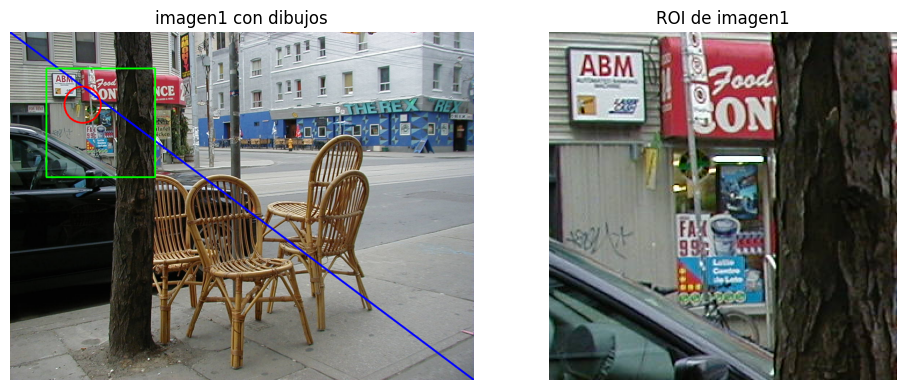

True

In [1]:

import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('imagen1.jpg')

if img is None:
    print("Error: no se pudo cargar imagen1.jpg")
else:
    print("--- imagen1.jpg ---")
    print("  Dimensiones:", img.shape)
    print("  Tipo de dato:", img.dtype)

# Lectura y escritura de un píxel puntual
valor_px = img[20, 20].copy()
print(f"Valor original en (20,20): {valor_px}")
img[20, 20] = [255, 255, 255]

# ROI (Region Of Interest)
roi = img[100:400, 100:400].copy()

# Dibujo de primitivas geométricas
img_draw = img.copy()
cv2.line(img_draw, (0, 0), (img_draw.shape[1], img_draw.shape[0]), (255, 0, 0), 3)
cv2.circle(img_draw, (200, 200), 50, (0, 0, 255), 3)
cv2.rectangle(img_draw, (100, 100), (400, 400), (0, 255, 0), 3)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB))
plt.title("imagen1 con dibujos")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
plt.title("ROI de imagen1")
plt.axis('off')

plt.tight_layout()
plt.show()

cv2.imwrite('resultado_1.png', img_draw)

---
## Ejercicio 2: Información de intensidad

--- Valores de Intensidad ---
  Punto (y=10, x=10): 161
  Punto (y=480, x=640): 100
  Punto (y=950, x=1270): 117


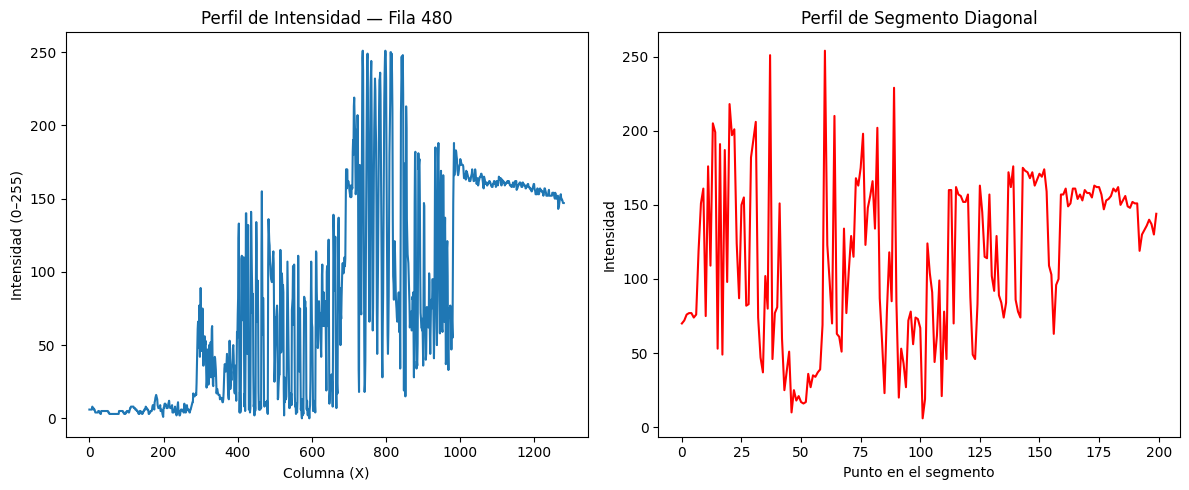

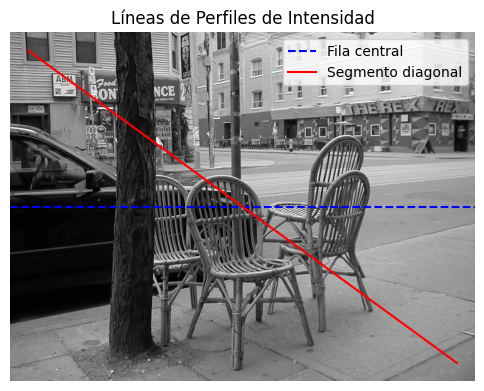

In [2]:
img = cv2.imread('imagen1.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
h, w = gray.shape

puntos = [(10, 10), (h // 2, w // 2), (h - 10, w - 10)]
print("--- Valores de Intensidad ---")
for y, x in puntos:
    print(f"  Punto (y={y}, x={x}): {gray[y, x]}")

# Perfil de intensidad sobre la fila central
fila_idx = h // 2
perfil_fila = gray[fila_idx, :]

# Perfil sobre un segmento diagonal
p0, p1 = (50, 50), (h - 50, w - 50)
num_puntos = 200
perfil_x = np.linspace(p0[1], p1[1], num_puntos).astype(int)
perfil_y = np.linspace(p0[0], p1[0], num_puntos).astype(int)
intensidad_segmento = gray[perfil_y, perfil_x]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(perfil_fila)
plt.title(f"Perfil de Intensidad — Fila {fila_idx}")
plt.xlabel("Columna (X)")
plt.ylabel("Intensidad (0–255)")

plt.subplot(1, 2, 2)
plt.plot(intensidad_segmento, color='red')
plt.title("Perfil de Segmento Diagonal")
plt.xlabel("Punto en el segmento")
plt.ylabel("Intensidad")

plt.tight_layout()
plt.show()

# Imagen con las líneas de muestreo marcadas
plt.figure(figsize=(6, 5))
plt.imshow(gray, cmap='gray')
plt.axhline(fila_idx, color='blue', linestyle='--', label='Fila central')
plt.plot([p0[1], p1[1]], [p0[0], p1[0]], color='red', label='Segmento diagonal')
plt.title("Líneas de Perfiles de Intensidad")
plt.legend()
plt.axis('off')
plt.show()

---
## Ejercicio 3: Detección del nivel de llenado en botellas

Se trabaja con `botellas.tif`, capturada en escala de grises desde una línea de envasado. El sistema localiza cada botella, verifica si está correctamente llena e informa el porcentaje de llenado.

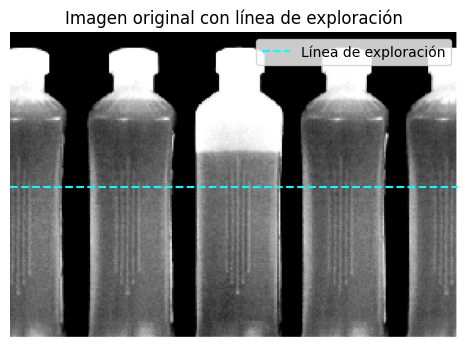

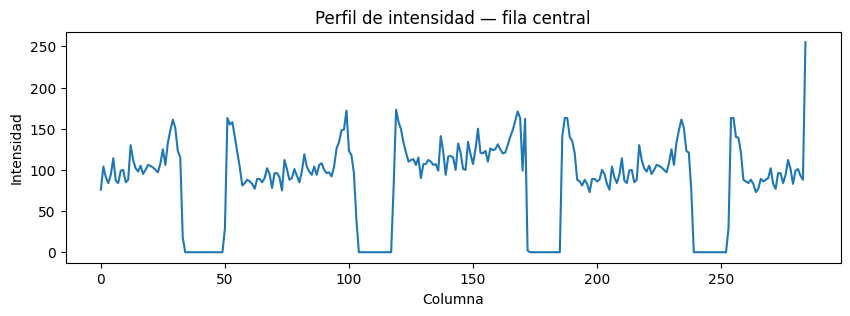

Bordes detectados: [  0  34  50 104 118 173 186 239 253 285]
Altura de la botella: 185 px (fila 11 a 196)

--- Porcentaje de llenado ---
  Botella 1: 81.1%  ⚠ INCOMPLETA
  Botella 2: 82.7%  ⚠ INCOMPLETA
  Botella 3: 65.4%  ⚠ INCOMPLETA
  Botella 4: 82.2%  ⚠ INCOMPLETA
  Botella 5: 82.2%  ⚠ INCOMPLETA


In [3]:
botellas = cv2.imread('botellas.tif', cv2.IMREAD_GRAYSCALE)

if botellas is None:
    print("Error: no se pudo cargar botellas.tif")
else:
    plt.figure(figsize=(10, 4))
    plt.imshow(botellas, cmap='gray')
    plt.axhline(botellas.shape[0] / 2, color='cyan', linestyle='--', label='Línea de exploración')
    plt.title("Imagen original con línea de exploración")
    plt.legend()
    plt.axis('off')
    plt.show()
    
    plt.figure(figsize=(10, 3))
    plt.plot(botellas[int(botellas.shape[0] / 2), :])
    plt.title("Perfil de intensidad — fila central")
    plt.xlabel("Columna")
    plt.ylabel("Intensidad")
    plt.show()
        # Detección de bordes de cada botella por transiciones en la fila central
    linea = botellas[int(botellas.shape[0] / 2), :]
    picos = []
    flag = True

    for i in range(len(linea)):
        if flag and linea[i] != 0:
            picos.append(i)
            flag = False
        elif not flag and linea[i] == 0:
            picos.append(i)
            flag = True

    picos = np.append(picos, botellas.shape[1])
    print(f"Bordes detectados: {picos}")

        # Altura útil de la botella
    col_central = int((picos[1] - picos[0]) / 2)
    linea_v = botellas[:, col_central]
    altura = []

    for i in range(len(linea_v)):
        if linea_v[i] != 0:
            altura.append(i + 1)
            break
    altura.append(botellas.shape[0])

    alt_total = altura[1] - altura[0]
    print(f"Altura de la botella: {alt_total} px (fila {altura[0]} a {altura[1]})")

        # Nivel de llenado de cada botella
    llenado = []

    for i in range(0, 10, 2):
        col = picos[i] + int((picos[i + 1] - picos[i]) / 2)
        linea_bot = botellas[altura[0]:, col]
        for j in range(len(linea_bot)):
            if 50 < linea_bot[j] < 200:
                llenado.append(j)
                break

    print("\n--- Porcentaje de llenado ---")
    for i in range(5):
        porcentaje = (alt_total - llenado[i]) / alt_total
        estado = "OK" if porcentaje >= 0.90 else "⚠ INCOMPLETA"
        print(f"  Botella {i+1}: {porcentaje:.1%}  {estado}")

